## Libaries

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd
import mne

from typing import Callable, Dict, List

from scipy.signal import iirnotch, lfilter, lfilter_zi, butter
from scipy.ndimage import median_filter
from scipy.ndimage import uniform_filter1d

parent_dir = Path().resolve().parent.parent
sys.path.append(str(parent_dir))

from src.utilities.preprocessing import Filtering, EEG_preprocessing, EMG_preprocessing, RejectBadEpochs      # noqa: E402
from src.utilities.load_and_visualize_data import load_datasets, visualize_EMG                    # noqa: E402
from src.utilities.EEG_feature_extraction import FeatureExtraction
from src.experiment.real_time_operation import EMGStreamProcessor

## Global variables

In [3]:
EMG_FREQ = 2000
EEG_FREQ = 125

EMG_LOWCUT = 20
EMG_HIGHCUT = 450
EEG_LOWCUT = 0.5
EEG_HIGHCUT = 30

EMG_NUM_CH = 3
EEG_NUM_CH = 16

TRIAL_PERIOD = 9
TRIM_PERIOD = 3

RMS_SAMPLING_WINDOW = 500          # 32
RMS_WINDOW_STEPSIZE = 50        # 16

HAMPEL_WINDOWSIZE = 100
HAMPEL_SIGMA = 2.0

EEG_CH_NAMES = [
    "Fp1", "Fp2",   # frontal pole
    "C3",  "C4",    # central
    "T5",  "T6",    # temporal (posterior)
    "Cz",  "Pz",    # occipital
    "F7",  "F8",    # temporal (anterior)
    "F3",  "F4",    # frontal
    "T3",  "T4",    # temporal (mid)
    "P3",  "P4"     # parietal
]
EMG_CH_NAMES =  [
        'Channel 1 : Palmaris longus',
        'Channel 2 : Flexor digitorum superficialis',
        'Channel 3 : Flexor pollicis longus',
        ]

EMG_CONFIG_DICT = {
    'rms_windowsize' : RMS_SAMPLING_WINDOW,
    'rms_stepsize' : RMS_WINDOW_STEPSIZE,
    'hampel_windowsize' : HAMPEL_WINDOWSIZE,
    'hampel_sigma' : HAMPEL_SIGMA,
    'hampel_plot_option' : [False, None],
    'include_EMG' : True
}

REJECT_CONFIG_DICT = {
    'EEG_epoch_rejection_tolerance' : 6,
    'EMG_epoch_rejection_tolerance' : 6,
    'EEG_ch_acceptance' : 0,
    'EMG_ch_acceptance' : 0
}

# EMG_CH_NAMES = [
# 'Channel 1 : Flexor digitorum superficialis',
# 'Channel 2 : Flexor pollicis longus', 
# 'Channel 3 : Extensor digitorum',
# 'Channel 4 : Extensor pollicis brevis/longus'
# ]

In [3]:
# ----- Global style -----

plt.rcParams.update({
    # ---- Font ----
    "font.family": "serif",
    #"font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    #"mathtext.fontset": "stix",
    #"text.usetex": False,          # True for LaTeX rendering (optional)
    
    # ---- Font sizes (A4 layout, 10 pt doc) ----
    "font.size": 9,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    
    # ---- Line and color ----
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "lines.markersize": 4,
    "axes.prop_cycle": plt.cycler(color=plt.cm.tab10.colors),

    # ---- Layout ----
    # Page size (247.000, 174.000) height, width
    # (5.5, 3.5) half-page 
    #"figure.figsize": (5.5, 3.5),  
    "figure.dpi": 400,
    "savefig.transparent": True,
    "savefig.bbox": "tight"
})

## Load multiple csv files

## EMG Section
### Load data

In [3]:
from src.models.classification_pipeline import Manage3Split
split_ins = Manage3Split(seed = 42)
#------------------------#
# Select what to inspect #
#------------------------#
base_dir = Path().resolve() / 'data'
EMG_ins = EMGStreamProcessor(fs = EMG_FREQ, lowcut=EMG_LOWCUT, highcut=EMG_HIGHCUT,
                             reject_config_dict = REJECT_CONFIG_DICT,
                             rms_window = 500, rms_step = 25,
                             hampel_window = 100, hampel_sigma = 2, base_dir = base_dir)



train_EMA = True
SUBJECTS_IDs = ['subject_0']
motion_list = ['thumb', 'index']
X_epoch = {}
X_labels = {}

for subj in SUBJECTS_IDs:
    X_epoch[subj] = {}
    X_labels[subj] = {}

    for ml in motion_list:
        data, num_epochs = EMG_ins.load_subject_data(subj = subj, finger = ml, modality = 'EMG', trim_period = TRIM_PERIOD, trial_period = TRIAL_PERIOD)    
        
        # Trial-level split
        train_idx, val_idx, test_idx = split_ins._split_trials(num_trials = num_epochs, train_ratio = 0.7)
        
        # Split each window into train, val, test sets
        X_epoch[subj][ml] = {}
        X_labels[subj][ml] = {}

        for split_name, split_indicies in zip(['train', 'val', 'test'], [train_idx, val_idx, test_idx]):
            split_data = data[split_indicies]
            
            X_e, y_e = EMG_ins.relabel_windows(
                epochs = split_data,
                window_samples = 1000,
                step_samples = 200,
                fs = EMG_FREQ,
                labels = ['rest', 'contract', 'release']
            )

            X_epoch[subj][ml][split_name] = X_e
            X_labels[subj][ml][split_name] = y_e

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0\EMG\flex_thumb_finger_2026-02-05 14-46-00.csv
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0\EMG\flex_thumb_finger_2026-02-05 14-51-56.csv
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0\EMG\flex_thumb_finger_2026-02-05 14-57-32.csv

=====FUNC : reject_routine =====

Final combined bad epoch indicies: [ 0  1 14 28]
Total bad epochs = 4 out of 90
Train split indicies (60,)
 Valdiation split indicies (13,)
 Test split indicies (13,)

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0\EMG\flex_index_finger_2026-02-05 14-19-21.csv
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0\EMG\flex_index_finger_2026-02-05 14-24-42.csv
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0\EMG\flex_index_finger_2026-02-05 14-37-01.csv

=====FUNC : reject_routine =====

Final combined bad epoch indicies: [ 0 13 51]
Total bad epochs = 3 out of 90
Train s

In [4]:
def normalize_global_per_channel(X_epoch, train_subjects : list):
    """
    Compute global mean/std from TRAIN data only (no leakage),
    and apply to train/val/test for all subjects and modalities.

    Parameters
    ----------
    X_epoch : dict
        Structure: X_epoch[subj][ml][split] -> (samples, seq_len, channels)

    Returns
    -------
    X_epoch : dict
        Normalized data (in-place modified)
    mu : np.ndarray
        Mean per channel (shape: channels,)
    sigma : np.ndarray
        Std per channel (shape: channels,)
    """

    # =========================
    # 1) Collect all TRAIN data
    # =========================
    X_train_all = []

    for subj in train_subjects:
        for ml in X_epoch[subj]:
            X_train_all.append(X_epoch[subj][ml]['train'])

    X_train_all = np.concatenate(X_train_all, axis=0)  # (N, seq_len, ch)

    # =========================
    # 2) Compute mean/std
    # =========================
    mu = np.mean(X_train_all, axis=(0, 1))       # (channels,)
    sigma = np.std(X_train_all, axis=(0, 1))     # (channels,)

    # =========================
    # 3) Normalize all splits
    # =========================
    norm_epochs = {}
    eps = 1e-8
    for subj in X_epoch:
        norm_epochs[subj] = {}

        for ml in X_epoch[subj]:
            norm_epochs[subj][ml] = {}

            for split in ['train', 'val', 'test']:
                X = X_epoch[subj][ml][split]

                X_norm = (X - mu) / (sigma + eps)

                norm_epochs[subj][ml][split] = X_norm

    return norm_epochs, mu, sigma

X_norm, mu, std = normalize_global_per_channel(X_epoch = X_epoch, train_subjects = ['subject_0'])

In [75]:
# 
def rms_conv2(signal, window_size=32, step_size=16):
    '''
    Convolution RMS. RMS = sqrt( LPF(x^2) ), where LPF is implemented as a uniform filter (moving average) over the squared signal.
    '''
    power = signal**2

    mean_power = uniform_filter1d(
        power,
        size=window_size,
        axis=0,
        mode="nearest"
    )

    rms = np.sqrt(mean_power)

    return rms[::step_size]

def preprocessing_routine2(  raw_emg : np.ndarray,
                            rms_windowsize : int = 200,
                            rms_stepsize : int = 50,
                            hampel_windowsize : int = 200,
                            hampel_sigma : int = 3.0,
                            hampel_plot_option : list = [False, None]) -> tuple[np.ndarray, np.ndarray, int]:
    '''
    Performs the full preprocessing routine:
    1) Notch + Bandpass filter
    2) Resample + z-score standardization + Secmentation into epochs

    :param dict raw_emg: This holds keys for a specfic class (finger). NOTE - If raw_emg is a list, it will be converted to a dict with key 'single_class'. 2D array - Dim(samples, channels)
    :param int bandpass_lowcut: Lowpass frequency
    :param int bandpass_highcut: Highpass frequency
    :param int num_channels: Number of activated channels
    :param int num_epochs: Number of epochs (trials) in the dataset
    :param int trial_period: Time of each epoch

    :return np.ndarray EMG: Normalized continuous EMG data - EMG(samples, channels)
    '''
    # ---------------------------#
    # 1) NOTCH + BANDPASS FILTER #
    # ---------------------------#
    EMG_filter_ins = Filtering(fs = 2000)        
    
    EMG_notch = EMG_filter_ins.notch(raw_emg, cutoff=50, Q=30)
    EMG_bandpass, _ = EMG_filter_ins.butter_bandpass(EMG_notch, lowcut = 20, highcut = 450, order=4)

    # -----------------#
    # 4) Hampel filter #
    # -----------------#
    EMG_hampel = EMG_filter_ins.hampel_filter(x = EMG_bandpass, window_size = hampel_windowsize, n_sigmas = hampel_sigma, plot_filter_results = hampel_plot_option)

    # -------#
    # 5) RMS #
    # -------#
    RMS = rms_conv2(signal = EMG_hampel, window_size = rms_windowsize, step_size = rms_stepsize)
    
    return RMS, EMG_hampel, num_epochs


con_emg = data.reshape(-1, 3)
filt_rms, filt_emg, _ = preprocessing_routine2(raw_emg=con_emg, rms_windowsize=500, rms_stepsize=50, hampel_windowsize=100, hampel_sigma=2)

In [4]:
X_epoch['subject_0']['thumb']['train'].shape, 1000/50

((4679, 21, 3), 20.0)

(array([31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47,
       48, 49, 50], dtype=int64),)


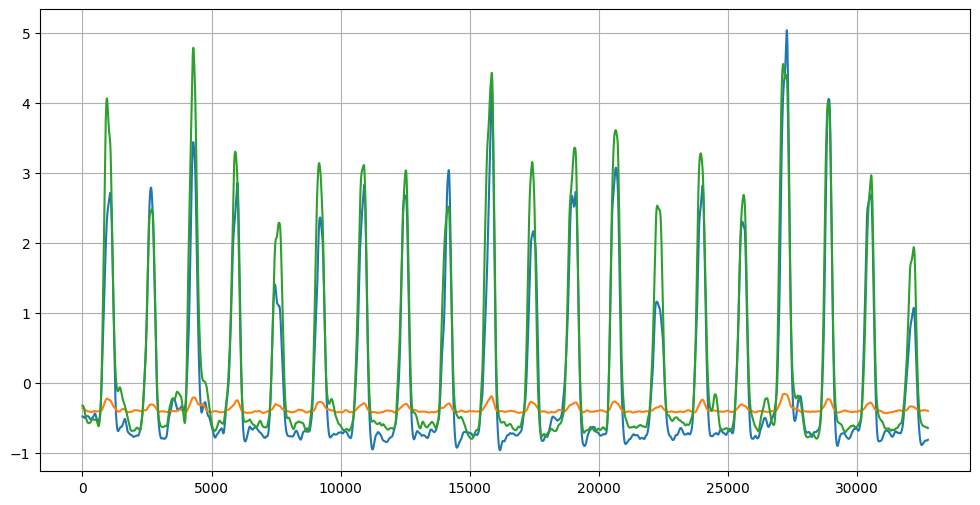

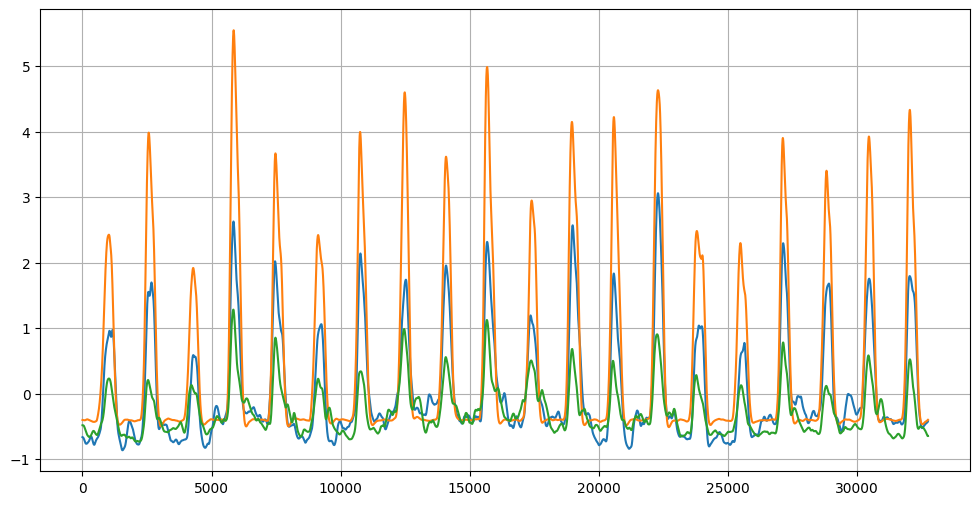

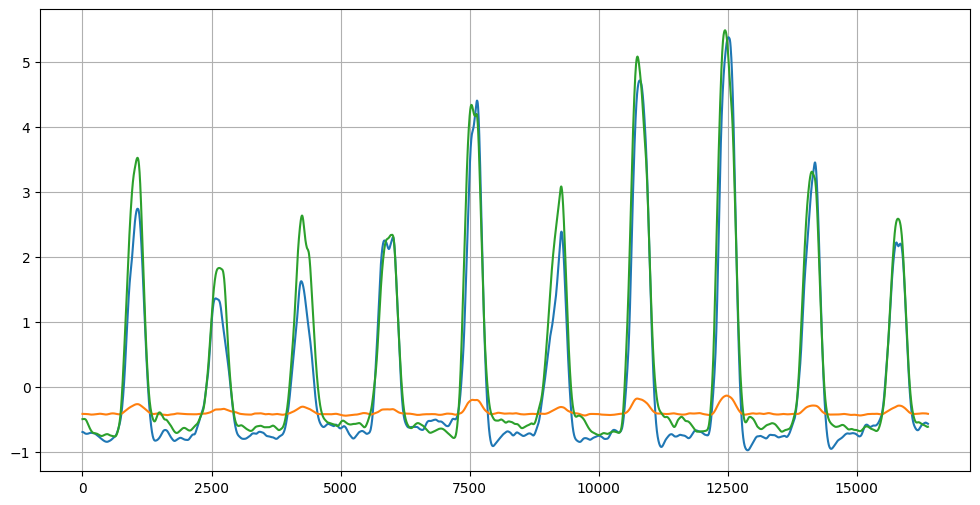

In [5]:
# glo_mean_filt = np.mean(filt_data, axis=0)
# glo_std_filt = np.std(filt_data.reshape(-1, 3), axis=0)

# eps = 1e-10
# X_norm_filt = (filt_data - glo_mean_filt) / (glo_std_filt + eps)

# X_epoch_norm, mu, sigma = normalize_global_per_channel(X_epoch)
X_epoch_norm = X_norm

# filt_ins = Filtering(fs = 2000)
# filt_rms = filt_ins.zscore(data = filt_rms)
# np.save("mu.npy", mu)
# np.save("sigma.npy", sigma)

#mu = np.load("mu.npy")
#sigma = np.load("sigma.npy")

X1 = X_epoch_norm['subject_0']['thumb']['train']
X2 = X_epoch_norm['subject_0']['index']['train']
X3 = X_epoch_norm['subject_0']['thumb']['test']
y = X_labels['subject_0']['thumb']['train']

X1_con = X1.reshape(-1, 3)
X2_con = X2.reshape(-1, 3)
X3_con = X3.reshape(-1, 3)

print(np.where(y[0:78] == 'contract'))

plt.figure(figsize=(12, 6))
plt.plot(X1_con[0 : 78*21*20, :])
plt.grid()

plt.figure(figsize=(12, 6))
plt.plot(X2_con[0 : 78*21*20, :])
plt.grid()

plt.figure(figsize=(12, 6))
plt.plot(X3_con[0 : 78*21*10, :])
plt.grid()

## EMG Section

### Normalization functions

In [ ]:
def MVC_EMG(json_filepath, EMG_raw):
    with open(fr'data\{json_filepath}') as f:
        calib_read = json.load(f)

    calib_dist = {}
    EMG_calib = []

    
    for k, (ch, value) in enumerate(calib_read.items()):
        ref = value['baseline_noise']
        mvc = value['MVC']
        print(f'baseline: {ref} \n mvc: {mvc}')
        
    
        calib_dist[ch] = {
            'ref' : ref,
            'mvc' : mvc
        }

        #print(f"{ch}: baseline={ref}, mvc={mvc}")
        
        if isinstance(EMG_raw, pd.DataFrame):
            normalized = ((EMG_raw.values[:, k] - ref) / (mvc - ref)) * 100
            EMG_calib.append(normalized)
            
        else:
            normalized = (EMG_raw[:, k] - ref) / (mvc - ref) * 100
            EMG_calib.append(normalized)
        
    EMG_calib = np.array(EMG_calib).T

    return EMG_calib

## Plot EMG

In [7]:
def mm_to_inches(mm):
    return mm / 25.4

def plot_emg_mean_epoch_single_channels(emg_epoch_mean1, rms_epoch_mean1, emg_epoch_mean2, rms_epoch_mean2, ch1 = 0, ch2 = 1):

    fig, axs = plt.subplots(
    1, 2,
    figsize=(mm_to_inches(162), mm_to_inches(60)),      # Before 162, 60
    dpi=400,                     # IMPORTANT
    gridspec_kw={"wspace": 0.05}, # spacing between figures
    sharey=True
    )
    #print('Channel Name :', EMG_CH_NAMES[emg_ch], 'and', EMG_CH_NAMES[rms_ch])

    emg1 = np.array(emg_epoch_mean1[:, ch1])
    rms1 = np.array(rms_epoch_mean1[:, ch1])

    emg2 = np.array(emg_epoch_mean2[:, ch2])
    rms2 = np.array(rms_epoch_mean2[:, ch2])

    ymax = np.max([rms1, rms2]) + 0.1
    ymin = np.min([emg1, emg2]) - 0.5
    time = np.arange(emg1.shape[0]) / EMG_FREQ
    
    win_time = (np.arange(rms1.shape[0]) * (50) + 50) / EMG_FREQ

    axs[0].plot(time, emg1, color='royalblue', linewidth=1.0, label = 'Index finger')
    axs[0].plot(win_time, rms1, color = 'orange', linewidth = 1.0, label = 'RMS envelope')
    axs[0].set_xlim([0, 9])
    #axs[0].set_ylim([ymin, ymax])
    axs[0].set_ylim([-1.555532, 2.6666623])
    axs[0].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Normalized EMG (a.u)')
    axs[0].axvline(3, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].axvline(6, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].grid(True, alpha=0.3)
    axs[0].legend(loc = 'lower left')

    axs[0].text(2, plt.ylim()[1]*0.99, 'Contract', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    axs[0].text(7, plt.ylim()[1]*0.99, 'Release', rotation=90, color='salmon', ha='left', va='top', fontsize=8)

    axs[1].plot(time, emg2, color='royalblue', linewidth=1.0, label='Thumb')
    axs[1].plot(win_time, rms2, color = 'orange', linewidth = 1.0, label = 'RMS envelope')
    axs[1].set_xlim([0, 9])
    axs[1].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[1].set_xlabel('Time (s)')
    axs[1].axvline(3, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].axvline(6, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].grid(True, alpha=0.3)
    axs[1].legend(loc = 'lower left')

    axs[1].text(2, plt.ylim()[1]*0.99, 'Contract', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    axs[1].text(7, plt.ylim()[1]*0.99, 'Release', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    
    print(f'print ymin: {ymin}, ymax: {ymax}')
    # plt.savefig(fr'images\subject8_report\Mean_EMG_epoch_index_ch{ch1}_and_thumb_ch{ch2}_normWI.pdf')
    # plt.savefig(fr'images\subject8_report\Mean_EMG_epoch_index_ch{ch1}_and_thumb_ch{ch2}_normWI.png')

print ymin: -1.474149954718816, ymax: 2.278185534858513


AttributeError: 'FigureManagerBase' object has no attribute 'window'

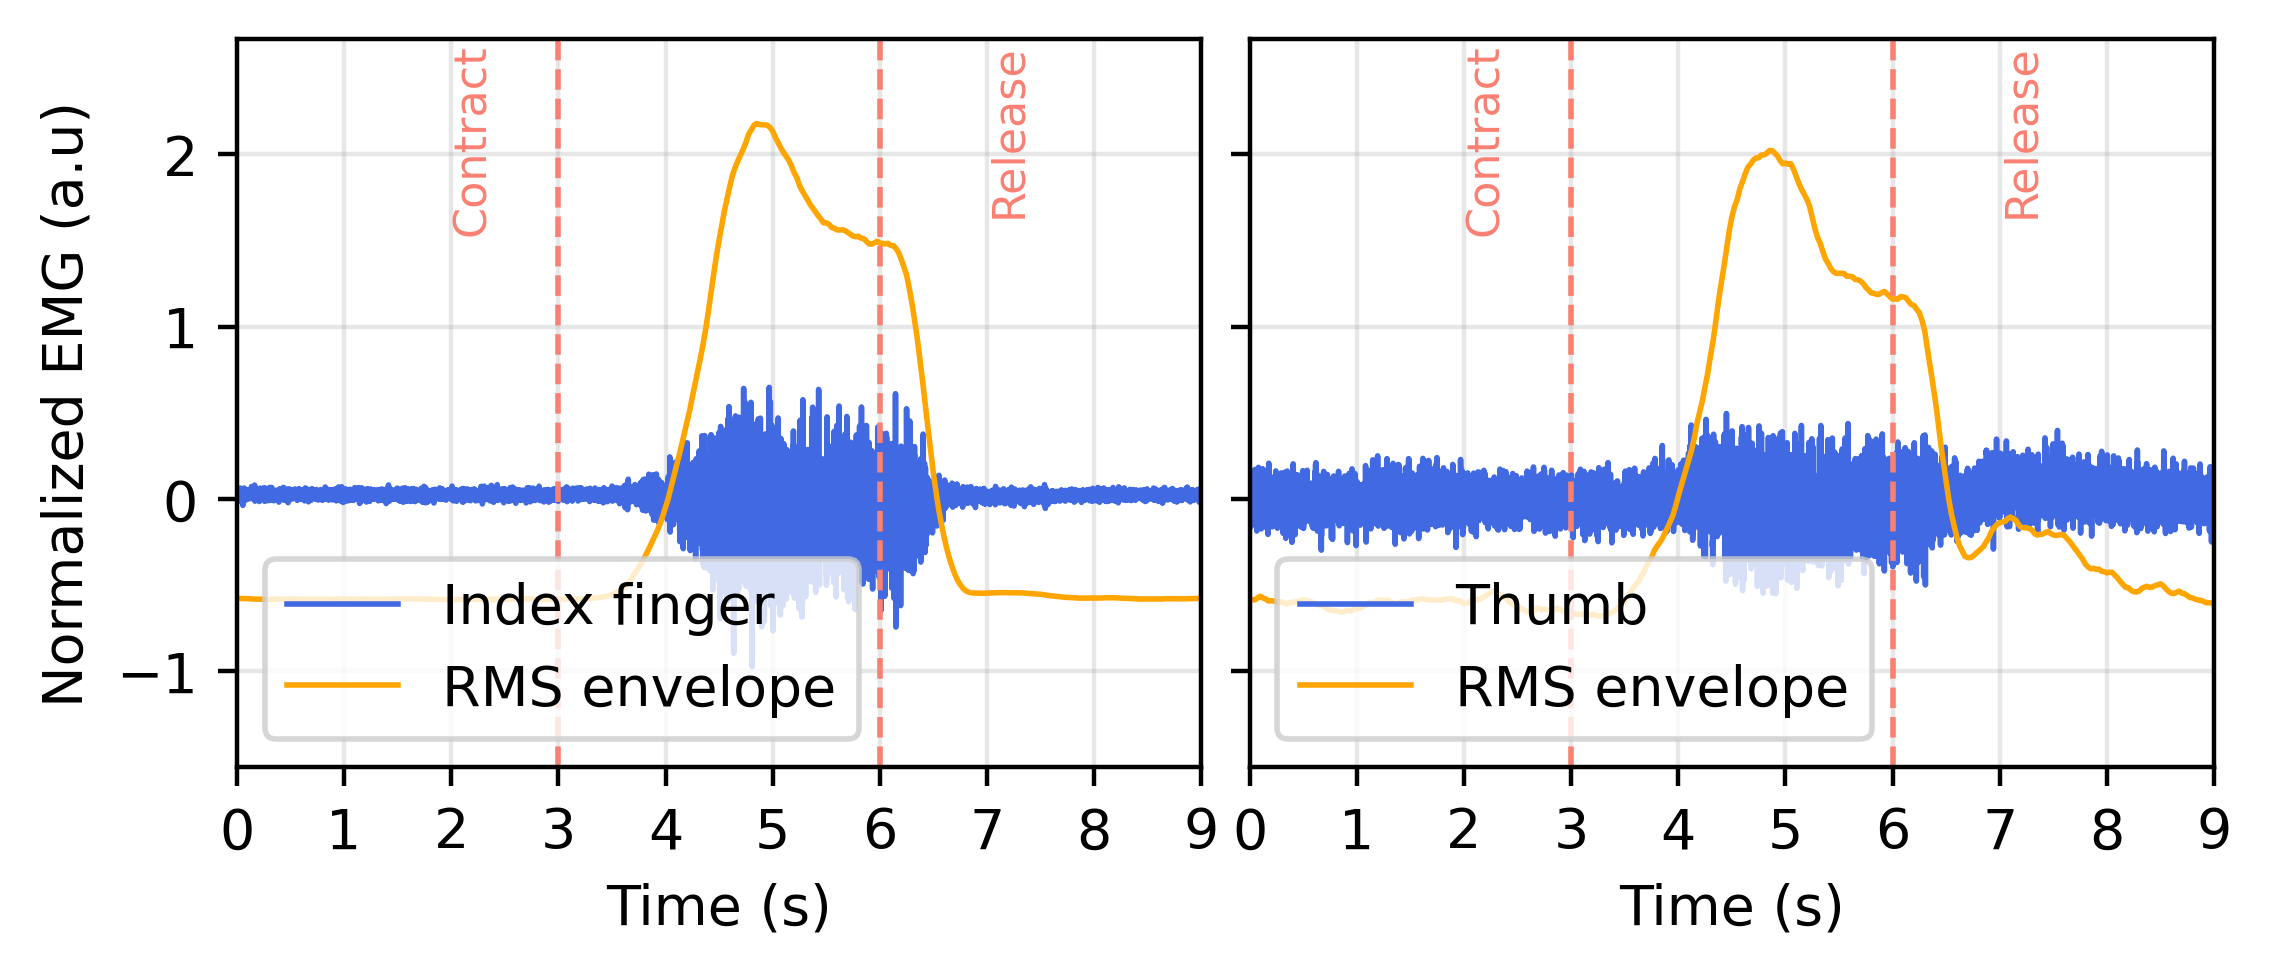

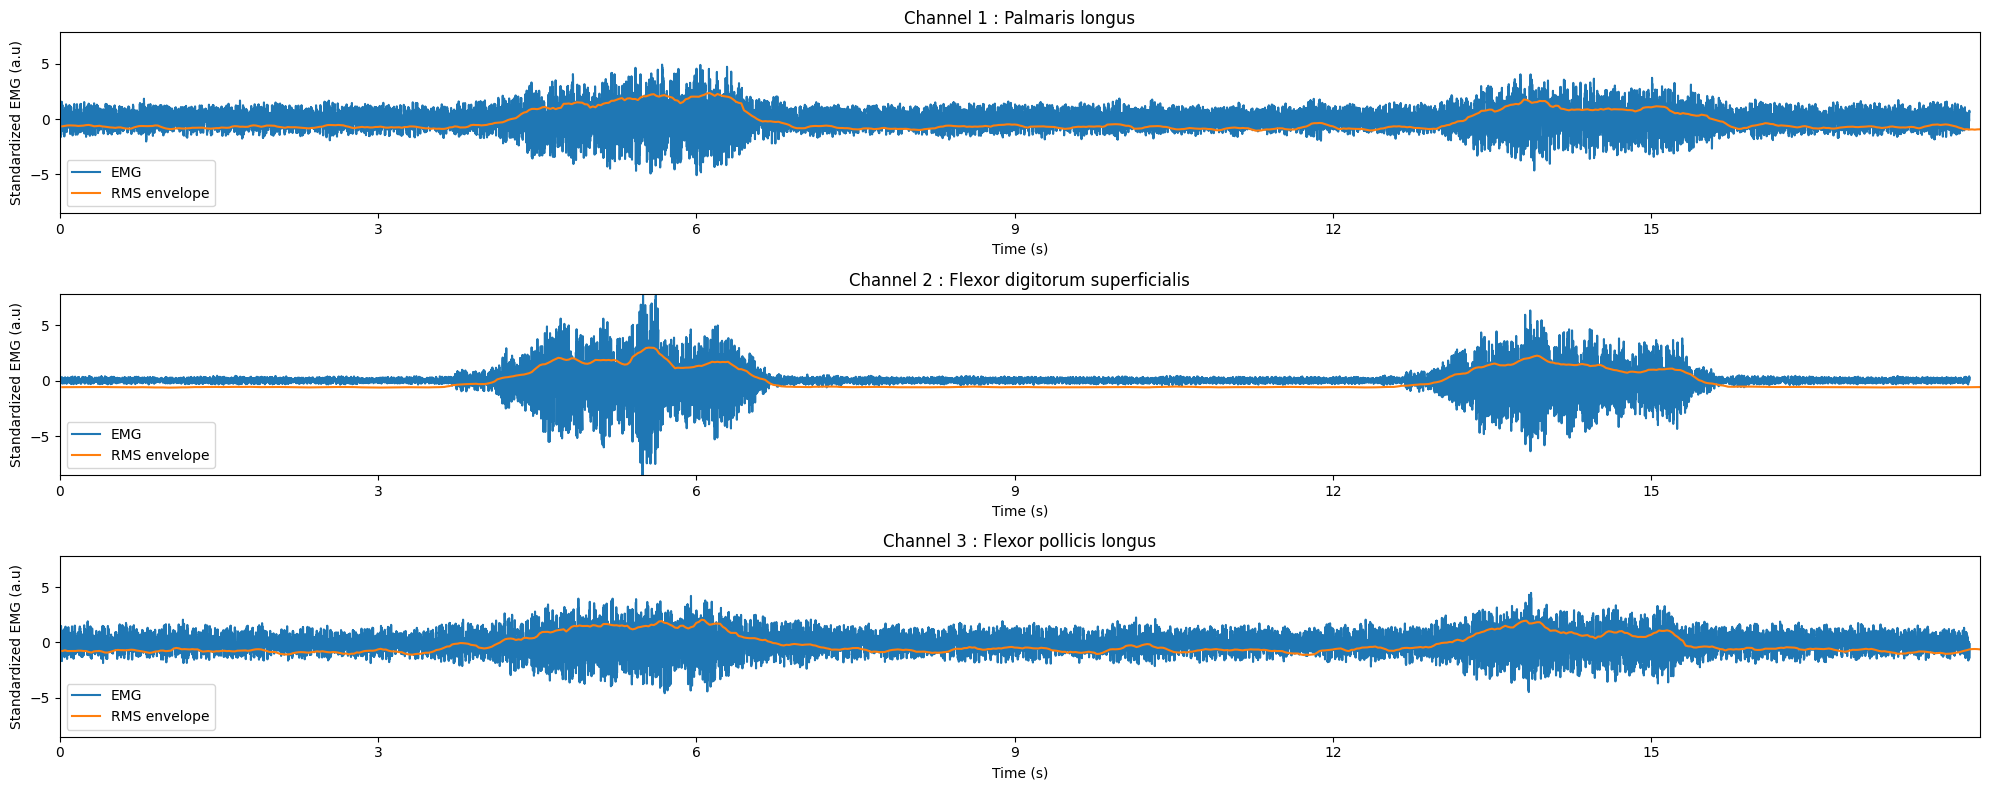

In [8]:
plot_emg_mean_epoch_single_channels(EMG_epoch_norm.mean(axis = 0), RMS_epoch_norm.mean(axis=0), EMG_epoch_norm.mean(axis=0), RMS_epoch_norm.mean(axis=0), ch1 = 1, ch2 = 2)

EMG_vis_ins = visualize_EMG(2000, 500, 50, len(epochs_overview), trial_period= 9 )

EMG_vis_ins.plot_rms_across_channels(emg = EMG_epoch_norm.reshape(-1, 3), rms = RMS_epoch_norm.reshape(-1, 3), markers = 0, display_window = [0, 18])

## Box plot

In [ ]:
def box_plot_across_channels(epoch_data, range_of_interst = 0):

    from matplotlib.ticker import FormatStrFormatter
    fingers = list(epoch_data.keys())
    n_ch = epoch_data[fingers[0]].shape[2]

    group_spacing = 1.2      # spacing between channels inside a finger-group
    finger_spacing = n_ch + 1 # spacing between finger groups

    if isinstance(range_of_interst, int):
        range_of_interst = np.arange(0, epoch_data[fingers[0]].shape[1])
        print('enter')

    # colors = [
    #     'royalblue',   # thumb
    #     'darkorange',  # index
    #     'forestgreen', # middle
    #     'firebrick',   # ring
    #     'purple',      # little
    #     'saddlebrown'  # palm
    # ]
    channel_colors = [
        'royalblue',   # ch1
        'darkorange',  # ch2
        'forestgreen', # ch3
    ]
    flierprops=dict(
        marker='*',
        markersize=0.5,
        markerfacecolor='black',
        markeredgecolor='black',
        alpha=0.6
    )

    positions = []
    labels = []
    all_box_data = []

    #plt.figure(figsize=(mm_to_inches(162/2), mm_to_inches(60)))
    fig, axs = plt.subplots(
    1, 2,
    figsize=(mm_to_inches(162), mm_to_inches(60)),      # Before 162, 60
    dpi=400,                     # IMPORTANT
    gridspec_kw={"wspace": 0.05}, # spacing between figures
    sharey=True
    )

    for f_idx, finger in enumerate(fingers):

        # data shape = (epochs, samples, channels)
        n_epo, n_sam, n_ch = epoch_data[finger][:, range_of_interst, :].shape
        # n_epo, n_ch = epoch_data[finger].shape

        # flatten epochs + samples
        EMG_flat = epoch_data[finger][:, range_of_interst, :].reshape(n_epo*n_sam, n_ch)
        # EMG_flat = epoch_data[finger]

        for ch in range(n_ch):            
            all_box_data.append(EMG_flat[:, ch])

            # compute x-position for this box
            pos = f_idx * finger_spacing + ch * group_spacing
            positions.append(pos)

            labels.append(f"{finger.capitalize()}  ch{ch+1}")

   # ---- Draw boxplot
    bp = axs[0].boxplot(
        all_box_data,
        positions=positions,
        widths=0.6,
        patch_artist=True,
        showfliers=False,
        flierprops = flierprops,
        medianprops=dict(color='black', linewidth=1.6),
        boxprops=dict(linewidth=1.0),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0)
    )

    # ---- Apply consistent channel colors
    for i, box in enumerate(bp['boxes']):
        ch = i % n_ch
        box.set_facecolor(channel_colors[ch])
        box.set_alpha(0.85)

        # ---- Aesthetics
    axs[0].set_xticks(positions, labels, rotation=15, ha='right')
    axs[0].set_ylabel("RMS envelope (a.u)")
    # axs[0].set_ylim([-1.555532, 2.6666623])
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    axs[0].grid(True, axis='y', linestyle='--', alpha=0.5)
    
    # plt.savefig(r'images\subject8_report\boxplot_RMS_normAC.pdf')
    # plt.savefig(r'images\subject8_report\boxplot_RMS_normAC.png')

In [228]:
RMS_dict = {}

RMS_dict['index'] = RMS_epoch_norm_index
RMS_dict['thumb'] = RMS_epoch_norm_thumb

ONE_SEC_RANGE = RMS_epoch_norm_index.shape[1] // TRIAL_PERIOD
CON_RANGE = np.arange(0*ONE_SEC_RANGE, 9*ONE_SEC_RANGE)

#box_plot_across_channels(RMS_dict)


## EEG Section

### Load datasets

In [75]:
def load_EEG_data(subject_name : str | list, finger_name : str, select_specfic_channels : list | None = None):
    EEG_USEABLE_CHANNELS = select_specfic_channels

    base_dir = Path().resolve() / 'data'

    load_ins = load_datasets(base_dir = base_dir)
    EEG_ins = EEG_preprocessing(fs = EEG_FREQ, bandpass_lowcut = EEG_LOWCUT, bandpass_highcut = EEG_HIGHCUT, trial_period = TRIAL_PERIOD, trim_period = TRIM_PERIOD)
    reject_ins = RejectBadEpochs(base_dir = base_dir)

    # Find EEG files
    EEG_files = load_ins.find_flex_files(
        subjects = subject_name,
        modality = "EEG",
        fingers = finger_name,
        prefix = 'flex'
    )

    # Load continous EEG data
    EEG, epochs_overview = load_ins.load_datasets_EEG(
        path_to_data_files = EEG_files,
        preprocessing_func = EEG_ins.preprocessing_routine
    )

    # Find bad epochs and return mask
    reject_mask = reject_ins.reject_routine(data_file_per_finger = EEG_files,
                                            epochs_overview = epochs_overview,
                                            EEG_data = EEG,
                                            RMS_data = None,
                                            reject_config_dict = REJECT_CONFIG_DICT,
                                            EEG_useable_channels = EEG_USEABLE_CHANNELS if EEG_USEABLE_CHANNELS is not None else None)

    total_epochs = sum(epochs_overview)
    EEG = EEG[:, EEG_USEABLE_CHANNELS].copy() if EEG_USEABLE_CHANNELS is not None else EEG
    EEG_epoch = EEG.reshape(total_epochs, EEG.shape[0] // total_epochs, EEG.shape[1])
    
    # Remove bad epochs
    EEG_epoch_clean = EEG_epoch[~reject_mask]

    # Perform CAR
    EEG_car = EEG_epoch_clean - np.mean(EEG_epoch_clean, axis = 2, keepdims = True)

    # Perform z-score normalization
    filt_ins = Filtering()
    EEG_epoch_norm = filt_ins.zscore(EEG_car, mode = 'within_ch')

    return EEG_epoch_norm

base_dir = Path().resolve() / 'data'
load_ins = load_datasets(base_dir = base_dir)
EEG_ins = EEG_preprocessing(fs = EEG_FREQ, bandpass_lowcut = EEG_LOWCUT, bandpass_highcut = EEG_HIGHCUT, trial_period = TRIAL_PERIOD, trim_period = TRIM_PERIOD)

# SUBJECTS_IDs = [f'subject_{subj}' for subj in range(17)]
SUBJECTS_IDs = ['subject_7']
motion_list = ['index', 'thumb']
EEG_USEABLE_CHANNELS = [2, 3, 6, 7, 8, 9, 10, 11]
EEG_dict = {}

for subj in SUBJECTS_IDs:
    EEG_dict[subj] = {}

    for ml in motion_list:
        
        EEG_temp, _ = load_ins.load_EEG_data(subject_name = subj,
                                          finger_name = ml,
                                          reject_config_dict = REJECT_CONFIG_DICT,
                                          preprocessing_func = EEG_ins.preprocessing_routine,
                                          EEG_useable_channels = None)

        EEG_dict[subj][ml] = EEG_temp

------------------
Process for EEG data
------------------

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_7\EEG\flex_index_finger_2026-02-18 13-00-27.csv
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_7\EEG\flex_index_finger_2026-02-18 13-07-54.csv
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_7\EEG\flex_index_finger_2026-02-18 13-13-36.csv

=====FUNC : reject_routine =====

Final combined bad epoch indicies: [ 1  7 16 21 25 45 77 79]
Total bad epochs = 8 out of 90
------------------
Process for EEG data
------------------

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_7\EEG\flex_thumb_finger_2026-02-18 13-20-56.csv
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_7\EEG\flex_thumb_finger_2026-02-18 13-28-20.csv
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_7\EEG\flex_thumb_finger_2026-02-18 13-34-42.csv

=====FUNC : reject_routine =====

Final combined bad epoch indicies: [ 8 5

In [ ]:
def plot_insert_markers(time_array, selected_time, marker_nonzero):
    color_list = {
    10 : 'salmon',
    20 : 'green',
    30 : 'yellow'
    }
    for i, mark in enumerate(marker_nonzero):
        t = time_array[i]
        if t > selected_time[-1]:
            break
        elif t < selected_time[0]:
            continue

        if mark in color_list.keys():
            plt.axvline(x=t, color=color_list[mark], linestyle='--', alpha=0.5)
            plt.text(t, plt.ylim()[1]*0.9, f'{mark}',
                    rotation=90, color='salmon', ha='left', va='top', fontsize=10
                )

def compute_ICA(rest_data, all_data):
    import mne
    _, n_channels = all_data.shape
    ch_names = [f"ch{i}" for i in range(n_channels)]
    ch_types = ["eeg"] * n_channels
    sfreq = 125

    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
    raw_rest = mne.io.RawArray(rest_data.T, info)
    raw_data = mne.io.RawArray(all_data.T, info)

    ica = mne.preprocessing.ICA(
    n_components=4,   # keep 99% variance OR use a fixed number like 15
    method='fastica',
    max_iter = 1000,
    random_state=97
    )

    #reject = dict(eeg = 80)
    ica.fit(raw_rest, reject=None)

    ica.plot_sources(inst = raw_rest, picks = None, start = 0, stop = 70, theme = 'dark')

    ica.exclude = [0]
    raw_clean = ica.apply(raw_data.copy())

    return raw_clean.get_data().T

## ERSP computational functions

In [ ]:
def compute_mrcp(epochs, baseline_start = 0.5, baseline_end = 2.5, fs = 125):
    """
    epochs shape: (n_epochs, n_samples, n_channels)

    baseline_samples:
        number of samples BEFORE movement onset
        e.g. 250 samples = 2 s at 125 Hz

    Returns
    -------
    mrcp : (n_samples, n_channels)
    """
    # 0.5 - 2.5 seconds before movement onset = 62.5 - 312.5 samples at 125 Hz
    r0 = int(baseline_start * fs)  # 62.5 samples = 62 samples (rounded down)
    k = int(baseline_end * fs)  # 312.5 samples = 312 samples (rounded down)

    # ---- 1) baseline each trial ----
    baseline = epochs[:, r0:k, :].mean(axis=1, keepdims=True)
    epochs_baselined = epochs - baseline

    # ---- 2) average trials (THIS is MRCP) ----
    mrcp = epochs_baselined.mean(axis=0)

    return mrcp

def compute_ERD_ERS_pfurtscheller(epoch, fs = 125):
    """
    resampled_data: (np.Array) 
        shape (n_samples, n_channels)
    """
    eps = 1e-12
    
    r0 = fs * 0     # samples for x seconds
    k = fs * 2      # samples for x seconds

    power = epoch**2
    
    # 3) Act(j): average power across trials
    Act = np.mean(power, axis=0)
    print(f'Act.shape: {Act.shape}')

    # 4) Baseline R
    baseline = Act[r0:r0+k, :]
    R = np.mean(baseline, axis = 0)

    print(f'R value: {R}')
    
    # 5) ERD/ERS
    rts = ((Act - R) / (R + eps)) * 100

    return rts

def plot_wavelet_spectrogram(epoch_mean, freq_bands={'mu': (8, 13), 'beta': (13, 30)}, freq_bins = 75):
    
    for freq_interst in freq_bands.keys():
        erd_ers, wt_freq = compute_erd_ers_pywt(epoch_mean = epoch_mean,
                                       freq_min = freq_bands[freq_interst][0], 
                                       freq_max = freq_bands[freq_interst][1],
                                       freq_bins = freq_bins)
    
        plt.figure(figsize=(10, 5))
        extent = [0, len(erd_ers)/EEG_FREQ, freq_bands['mu'][0], freq_bands['beta'][1]]
        
        for sch in range(EEG_NUM_CH):
            X = erd_ers[:, sch]

            plt.imshow(
                [X, wt_freq],
                aspect='auto',
                origin='lower',
                extent=extent,
                cmap='turbo'
            )

    plt.colorbar(label="Power change (%)")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Baseline-corrected Wavelet Spectrogram\nChannel {EEG_CH_NAMES[sch]}")
    plt.axhline(8, color='white', linestyle='--', alpha=0.6)
    plt.axhline(13, color='white', linestyle='--', alpha=0.6)
    plt.axhline(30, color='white', linestyle='--', alpha=0.6)
    plt.show()

import numpy as np
from scipy.signal import butter, sosfiltfilt, hilbert

def compute_erd(
    epochs,
    fs,
    baseline_start = 0,
    baseline_end = 3
):
    """
    epochs: (n_epochs, n_samples, n_channels)
    Epoch structure:
        0-3s   : REST
        3-6s   : MOVE
        6-9s   : RELEASE
    """

    # 2) Power
    power = np.abs(hilbert(epochs, axis=1)) ** 2

    # 4) Baseline = REST
    b0 = int(baseline_start * fs)
    b1 = int(baseline_end * fs)
    
    R = np.mean(power[:, b0:b1, :], axis=1, keepdims=True)

    # 5) ERD%
    erd = (power - R) / (R + 1e-12) * 100.0

    return erd

def compute_erd_pywt(data, markers, band = (2, 32), freq_min = 8, freq_max = 12, freq_bins = 75, rest_sec = 3.0, baseline_sec = (-3.0, 0.0), fs = 125):
    import pywt
    wt_obj = "morl"
    wt_dt = 1.0/fs

    wt_freqs_interst = np.linspace(freq_min, freq_max, freq_bins)
    wt_scales = pywt.frequency2scale(wt_obj, wt_freqs_interst) / wt_dt

    EEG_ins = EEG_preprocessing(125)

    # 1) Bandpass
    sos = butter(4, band, btype="bandpass", fs=fs, output="sos")
    x = sosfiltfilt(sos, data, axis=0)

    marker_idx = np.nonzero(markers)[0]
    x_trim, total_epochs = EEG_ins.trim_trial_periods(x, markers, marker_idx, 'ALL', 9)
    
    # Make epochs
    n_samples, n_ch = x_trim.shape
    EEG_samples_per_epoch = n_samples // total_epochs      
    epoch = x_trim.reshape(total_epochs, EEG_samples_per_epoch, n_ch)
    # epoch_car = epoch - epoch.mean(axis = 2, keepdims = True)


    wt_coef, wt_freq = pywt.cwt(
        data =  epoch,              # (E, S, C)
        scales = wt_scales,         # (F)
        wavelet = wt_obj,
        method = 'conv',
        sampling_period=wt_dt,
        precision = 12,
        axis = 1
    )   # Coef: (F, E, S, C)

    # 2) Power
    power = np.abs(wt_coef) ** 2
    #power = np.abs(hilbert(epoch_car, axis=1)) ** 2

    print(f"Samples per epoch: {EEG_samples_per_epoch} - Without // : {n_samples / total_epochs}")
    print(f"Reshaped data shape: {power.shape}")
    print(f"Epoched data shape: {epoch.shape}")

    # 3) Onset index (movement starts after REST)
    onset_idx = int(rest_sec * fs)

    # 4) Baseline = REST
    b0 = onset_idx + int(baseline_sec[0] * fs)  # = 0
    b1 = onset_idx + int(baseline_sec[1] * fs)  # = onset_idx

    R = np.mean(power[:, b0:b1, :], axis=2, keepdims=True)      # (F, E, 1, C)

    # 5) ERD%  
    erd_all = (power - R) / (R + 1e-12) * 100.0                 # (F, E, S, C)
    erd_mean = erd_all.mean(axis=1)                             # (F, S, C)

    return erd_mean, erd_all, wt_freq


### Plot functions

In [55]:
#-------------#
# NEWEST PLOT #
#-------------#
def mm_to_inches(mm):
    return mm / 25.4

# THIS ONE FOR REPORT
def plot_mean_epoch_single_channels(data, ch1 = 0, ch2 = 1, finger1 = None, finger2 = None, list_of_channels = None):
    fig, axs = plt.subplots(
    1, 2,
    figsize=(mm_to_inches(450), mm_to_inches(200)),      # 162, 60
    #dpi=200,                     # IMPORTANT            # 400
    gridspec_kw={"wspace": 0.05}, # spacing between figures
    sharey=True
    )
    ch1_print = list_of_channels[ch1]
    ch2_print = list_of_channels[ch2]
    print('Channel Name :', EEG_CH_NAMES[ch1_print], 'and', EEG_CH_NAMES[ch2_print])

    data1 = np.mean(data[finger1], axis = 0)
    data2 = np.mean(data[finger2], axis = 0)
    
    time = np.arange(data1.shape[0]) / EEG_FREQ
    ymax = max(np.max(data1[:, ch1]), np.max(data2[:, ch2]))
    ymin = min(np.min(data1[:,ch1]), np.min(data2[:,ch2]))


    axs[0].plot(time, data1[:, ch1], color='royalblue', linewidth=1.0, label='Index finger')
    axs[0].set_xlim([0, 9])
    #axs[0].set_ylim([-10, 10])
    axs[0].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Normalized EEG (a.u)')
    axs[0].axhline(0, color = 'grey', linestyle='--', linewidth=0.5)
    axs[0].axvline(3, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].axvline(6, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(time, data2[:, ch2], color='royalblue', linewidth=1.0, label='Thumb finger')
    axs[1].set_xlim([0, 9])
    #axs[1].set_ylim([-0.6, 0.6])
    axs[1].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[1].set_xlabel('Time (s)')
    #axs[1].set_ylabel('Normalized EEG (a.u)')
    axs[1].axvline(3, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].axvline(6, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].grid(True, alpha=0.3)
    print('Ymax: ', ymax, 'Ymin: ', ymin)
    # plt.savefig(fr'images\subject8_report\MRCP_{finger1}_{EEG_CH_NAMES[ch1]}_and_{finger2}_{EEG_CH_NAMES[ch2]}_report.pdf')
    # plt.savefig(fr'images\subject8_report\MRCP_{finger1}_{EEG_CH_NAMES[ch1]}_and_{finger2}_{EEG_CH_NAMES[ch2]}_report.png')

def plot_compare_data_means(data1, data2, fs, title, list_of_channels):
    n_samples, n_channels = data1.shape
    time = np.arange(n_samples) / fs

    ymax = np.max((np.max(data1), np.max(data2)))
    ymin = np.min((np.min(data1), np.min(data2)))

    if list_of_channels is not None:
        display_channels = list_of_channels
        num_rows = len(display_channels)
        print(display_channels)
    else:
        display_channels = np.arange(n_channels)
        num_rows = n_channels
        print(display_channels)

    fig, axes = plt.subplots(nrows = num_rows, ncols = 1, figsize = (10, 3 * num_rows))

    for i, ch in enumerate(display_channels):
        ax = axes[i]

        ax.plot(time, data1[:, ch], linewidth=2)
        ax.plot(time, data2[:, ch], linewidth=2)

        for t in range(5):
            # 0, 3, 6, 9,   9, 12, 15, 18,   18, 21, 24, 27
            th = t*9
            ax.axvline(0+th, linestyle="--", color="grey", alpha=0.6, label="Move onset")
            ax.axvline(3+th, linestyle="--", color="green", alpha=0.6, label="Move onset")
            ax.axvline(6+th, linestyle="--", color="red", alpha=0.6, label="Release onset")

        ax.axhline(0, color="gray", linewidth=1)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("ERD (%)")
        ax.set_title(f'Channel {EEG_CH_NAMES[ch]}')

        ax.set_ylim(ymin, ymax)
        ax.set_xticks(np.arange(0, 50, 3))
        ax.set_xlim(0, 50)
    
    fig.suptitle(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_erd_single_trials(erd_all, fs, ch_idx, n_trials=20):
    n_epochs, n_samples, _ = erd_all.shape
    time = np.arange(n_samples) / fs

    plt.figure(figsize=(10, 6))

    for i in range(min(n_trials, n_epochs)):
        plt.plot(time, erd_all[i, :, ch_idx], alpha=0.3)

    plt.axvline(3, linestyle="--", color="k", alpha=0.6)
    plt.axvline(6, linestyle="--", color="k", alpha=0.6)
    plt.axhline(0, color="gray", linewidth=1)

    plt.xlabel("Time (s)")
    plt.ylabel("ERD (%)")
    plt.title(f"Single-trial ERD (Channel {ch_idx})")
    plt.tight_layout()
    plt.show()

def plot_erd_time_frequency(
    erd_tf_mean,
    freqs,
    fs,
    ch_idx,
    vmin=-50,
    vmax=50,
    title="ERD Time-Frequency"
):
    """
    erd_tf_mean: (F, T, C)
    freqs: (F,)
    """
    F, T, _ = erd_tf_mean.shape
    time = np.arange(T) / fs

    plt.figure(figsize=(10, 4))
    plt.pcolormesh(
        time,
        freqs,
        erd_tf_mean[:, :, ch_idx],
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )

    plt.axvline(3, color="k", linestyle="--", linewidth=1)
    plt.axvline(6, color="k", linestyle="--", linewidth=1)

    plt.colorbar(label="ERD (%)")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_erd_band_time(
    erd_tf_mean,
    freqs,
    fs,
    ch_idx,
    title="Band-averaged ERD"
):
    """
    erd_tf_mean: (F, T, C)
    """
    time = np.arange(erd_tf_mean.shape[1]) / fs

    erd_band = erd_tf_mean[:, :, ch_idx].mean(axis=0)  # avg over freq

    plt.figure(figsize=(10, 4))
    plt.plot(time, erd_band, linewidth=2)

    plt.axvline(3, color="k", linestyle="--", label="Move onset")
    plt.axvline(6, color="k", linestyle="--", label="Release onset")
    plt.axhline(0, color="gray", linewidth=1)

    plt.xlabel("Time (s)")
    plt.ylabel("ERD (%)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


Channel Name : F8 and F8
Ymax:  0.35936752534338023 Ymin:  -0.32232133374941613


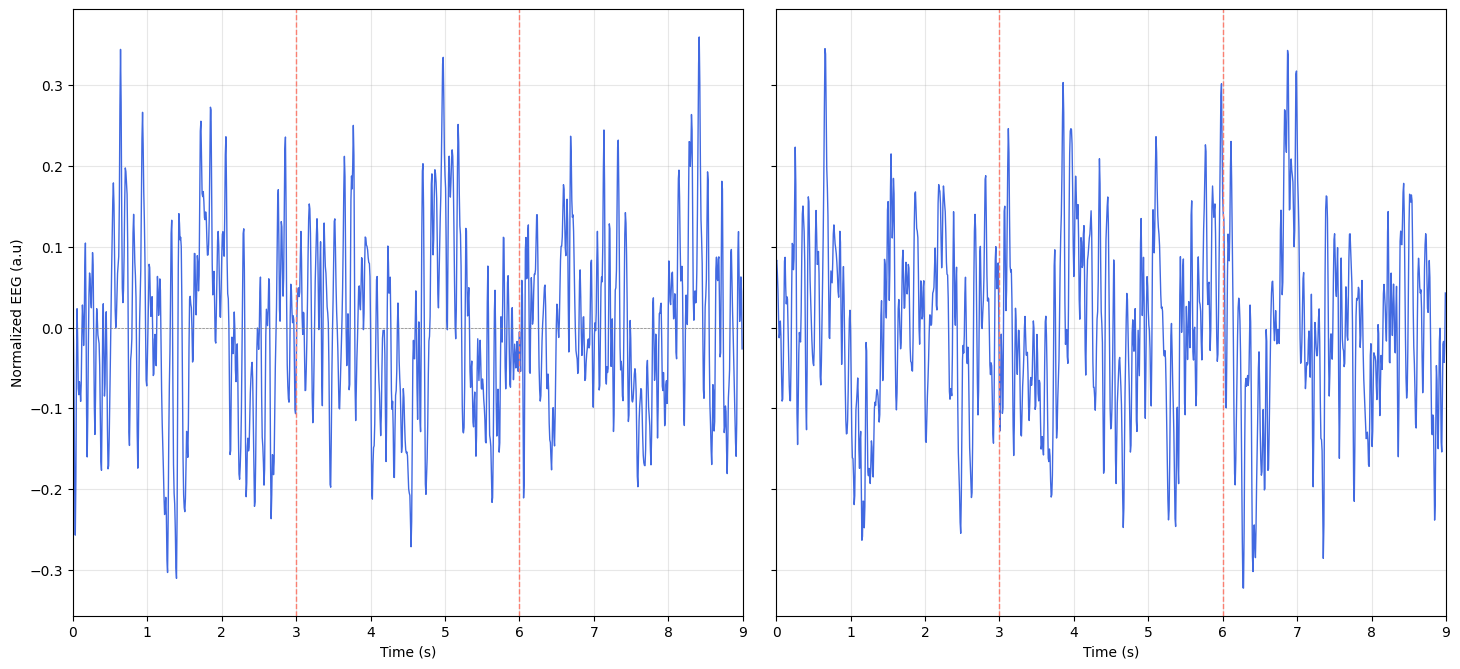

In [76]:
# NOTE: Do only over C3, C4, Cz
# Note: Try without Norm
#==============#
# Compute MRCP #
#==============#
# ERD_index = compute_erd(EEG_epoch_norm_index, fs = 125, baseline_start = 0.0, baseline_end = 3.0)
# ERD_thumb = compute_erd(EEG_epoch_norm_thumb, fs = 125, baseline_start = 0.0, baseline_end = 3.0)
#=================#
# Plot for report #
#=================#
# EEG_epoch_dict = {}
# EEG_epoch_dict['index'] = ERD_index.mean(axis=0)
# EEG_epoch_dict['thumb'] = ERD_thumb.mean(axis=0)

data_plot = EEG_dict['subject_7']

topo_data = {}
topo_data['index'] = np.mean(EEG_dict['subject_7']['index'], axis = 0)
topo_data['thumb'] = np.mean(EEG_dict['subject_7']['thumb'], axis = 0)

plot_mean_epoch_single_channels(data = data_plot, ch1 = 5, ch2 = 5, finger1 = 'index', finger2 = 'thumb', list_of_channels = EEG_USEABLE_CHANNELS)
# plot_mean_epoch_single_channels(data = EEG_epoch_dict, ch1 = 1, ch2 = 1, finger1 = 'index', finger2 = 'thumb')
# plot_mean_epoch_single_channels(data = EEG_epoch_dict, ch1 = 2, ch2 = 2, finger1 = 'index', finger2 = 'thumb')

## Visualize topoplot with MNE

### 1. Load your custom electrode positions (.sfp)

In [77]:
channel_location_dir = str(parent_dir) + "\\src\\utilities\\electrode_positions_16channel_modifed.sfp"

montage = mne.channels.read_custom_montage(channel_location_dir)
montage

<DigMontage | 0 extras (headshape), 0 HPIs, 0 fiducials, 16 channels>

### 2. Create MNE Info object

In [78]:
ch_names = montage.ch_names
n_channels = len(ch_names)

info = mne.create_info(
    ch_names = ch_names,
    sfreq = EEG_FREQ,
    ch_types = 'eeg'
)

# Attach your custom montage
info.set_montage(montage)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, C3, C4, T5, T6, Cz, Fz, F7, F8, F3, F4, T3, T4, P3, P4
 chs: 16 EEG
 custom_ref_applied: False
 dig: 19 items (3 Cardinal, 16 EEG)
 highpass: 0.0 Hz
 lowpass: 62.5 Hz
 meas_date: unspecified
 nchan: 16
 projs: []
 sfreq: 125.0 Hz
>

### 3. Convert your numpy epochs into MNE Epochs

In [79]:
'''# Reshape, because MNE needs the dimensions of: (n_epochs, n_channels, n_samples)
select_data_epoch_index = MRCP['index'].transpose(1, 0).copy() * 1e-6   # convert µV → V
select_data_epoch_thumb = MRCP['thumb'].transpose(1, 0).copy() * 1e-6   # convert µV → V 

epochs_mne_index = mne.EpochsArray(select_data_epoch_index, info=info, verbose=False)
epochs_mne_thumb = mne.EpochsArray(select_data_epoch_thumb, info=info, verbose=False)

# Compute evoked response (average across epochs)
evoked_index = epochs_mne_index.average()
evoked_thumb = epochs_mne_thumb.average()'''

tmin = 0.0  # Start of epoch (3 seconds before movement onset)

mrcp_volt_ix = topo_data['index'].T   
mrcp_volt_tb = topo_data['thumb'].T   

evoked_index = mne.EvokedArray(mrcp_volt_ix, info=info, tmin=tmin, verbose=False)
evoked_thumb = mne.EvokedArray(mrcp_volt_tb, info=info, tmin=tmin, verbose=False)

combining channels using "mean"
combining channels using "mean"


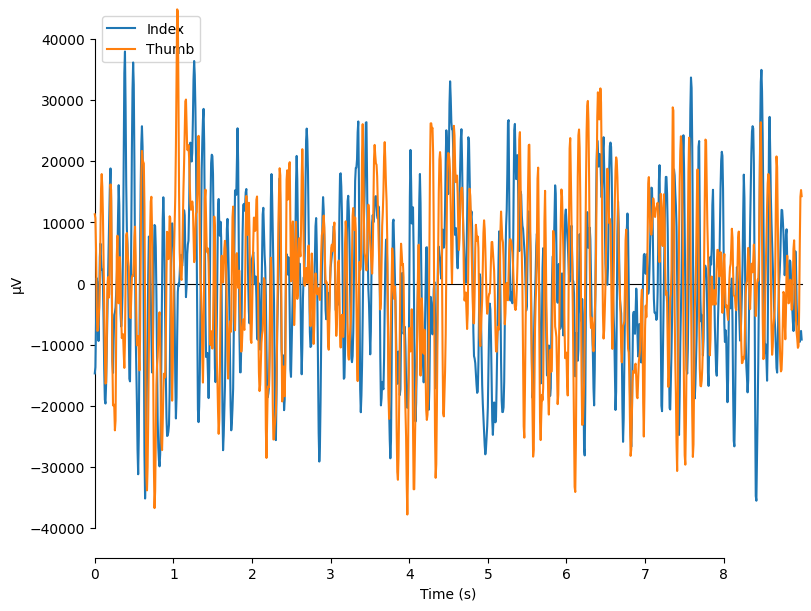

[<Figure size 800x600 with 1 Axes>]

In [80]:
mne.viz.plot_compare_evokeds(
    {
        "Index": evoked_index,
        "Thumb": evoked_thumb
    },
    combine="mean"
)

### 4. Create a beautiful topoplot

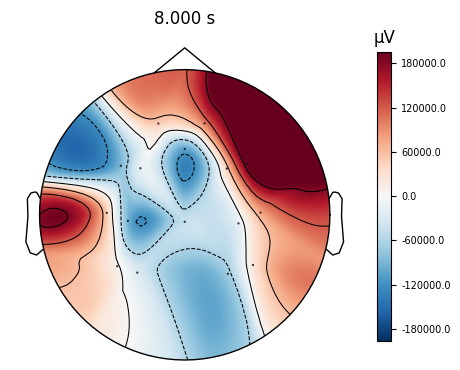

In [81]:
# Time (in seconds) you want to visualize
time_to_plot = 8

fig = evoked_index.plot_topomap(
    times=[time_to_plot],
    ch_type='eeg',
    cmap='RdBu_r',
    size=3,
    show=False
)

plt.show()

### 5. Multiple topoplots across time

In [82]:
# Keep to remain the scale
all_data = np.concatenate([mrcp_volt_ix, mrcp_volt_tb], axis=1)
vmax = np.percentile(np.abs(all_data), 99)
# vmax = np.max(np.abs(all_data))
vlim = (-vmax, vmax)

vlim

(-0.3143555972032306, 0.3143555972032306)

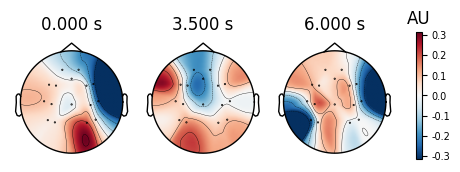

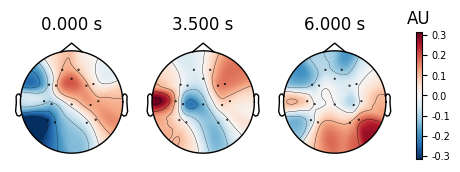

In [87]:
times = [0.0, 3.5, 6.0]   # seconds relative to your epoch start

fig_ix = evoked_index.plot_topomap(
    times=times,
    ch_type='eeg',
    cmap='RdBu_r',
    size=1,
    time_unit='s',
    scalings=1,
    vlim=vlim,
    show=True
)

# fig_ix.savefig(
#     r"images\subject8_report\topomap_index.png",
#     bbox_inches="tight"
# )

fig_tb = evoked_thumb.plot_topomap(
    times=times,
    ch_type='eeg',
    cmap='RdBu_r',
    size=1,
    time_unit='s',
    scalings=1,
    vlim=vlim,
    show=True
)

# fig_tb.savefig(
#     r"images\subject8_report\topomap_thumb.png",
#     bbox_inches="tight"
# )

### 7. Compare two classes: thumb vs index

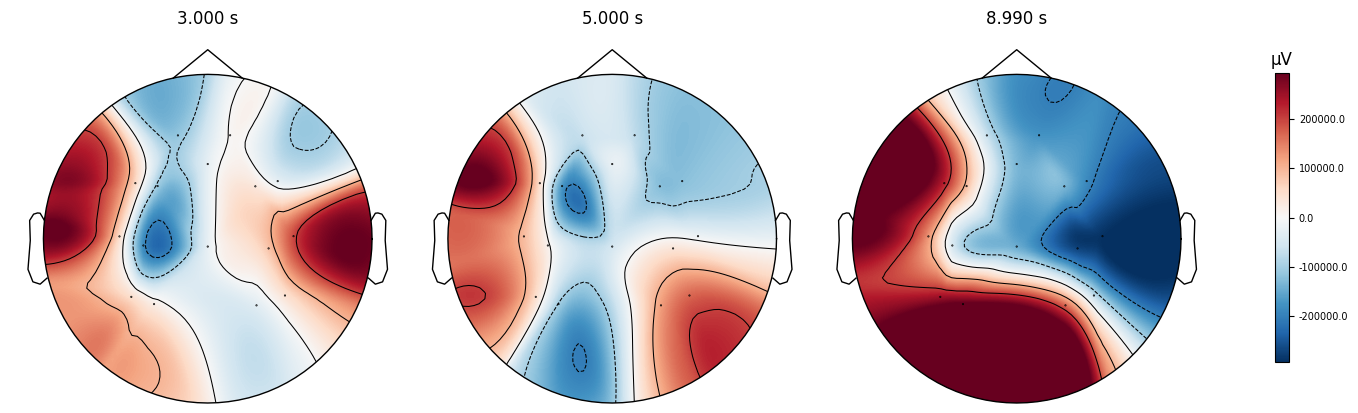

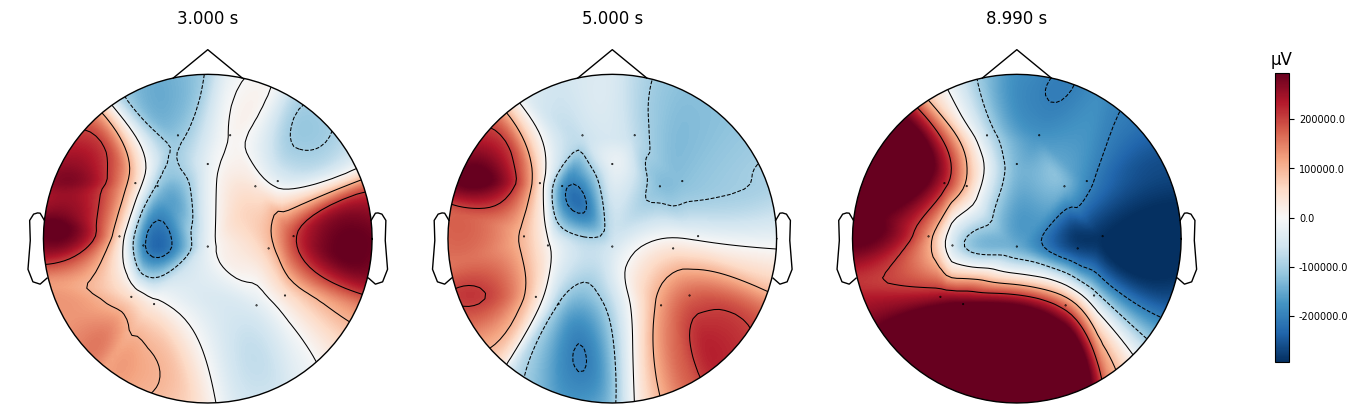

In [85]:
# Difference map
evoked_diff = mne.combine_evoked([evoked_index, evoked_thumb], weights=[1, -1])

evoked_diff.plot_topomap(times=[3, 5, 8.99], cmap='RdBu_r', size=3)


## Step-by-step solution: windowed topomaps

## 1. Extract window-averaged topographies

In [54]:
# Define time window 
time_windows = [
    (0.6, 1.0),
    (2.6, 3.0),
    (7.6, 8.0)
]

topomaps = []
times_for_plot = []

for tmin, tmax in time_windows:
    # Crop evoked to window
    evoked_win = evoked_index.copy().crop(tmin=tmin, tmax=tmax)

    # Average across time → (n_channels,)
    topo = evoked_win.data.mean(axis=1)
    topomaps.append(topo)

    # For labeling only
    times_for_plot.append((tmin + tmax) / 2)

## 3. Plot them as a row of scalp maps

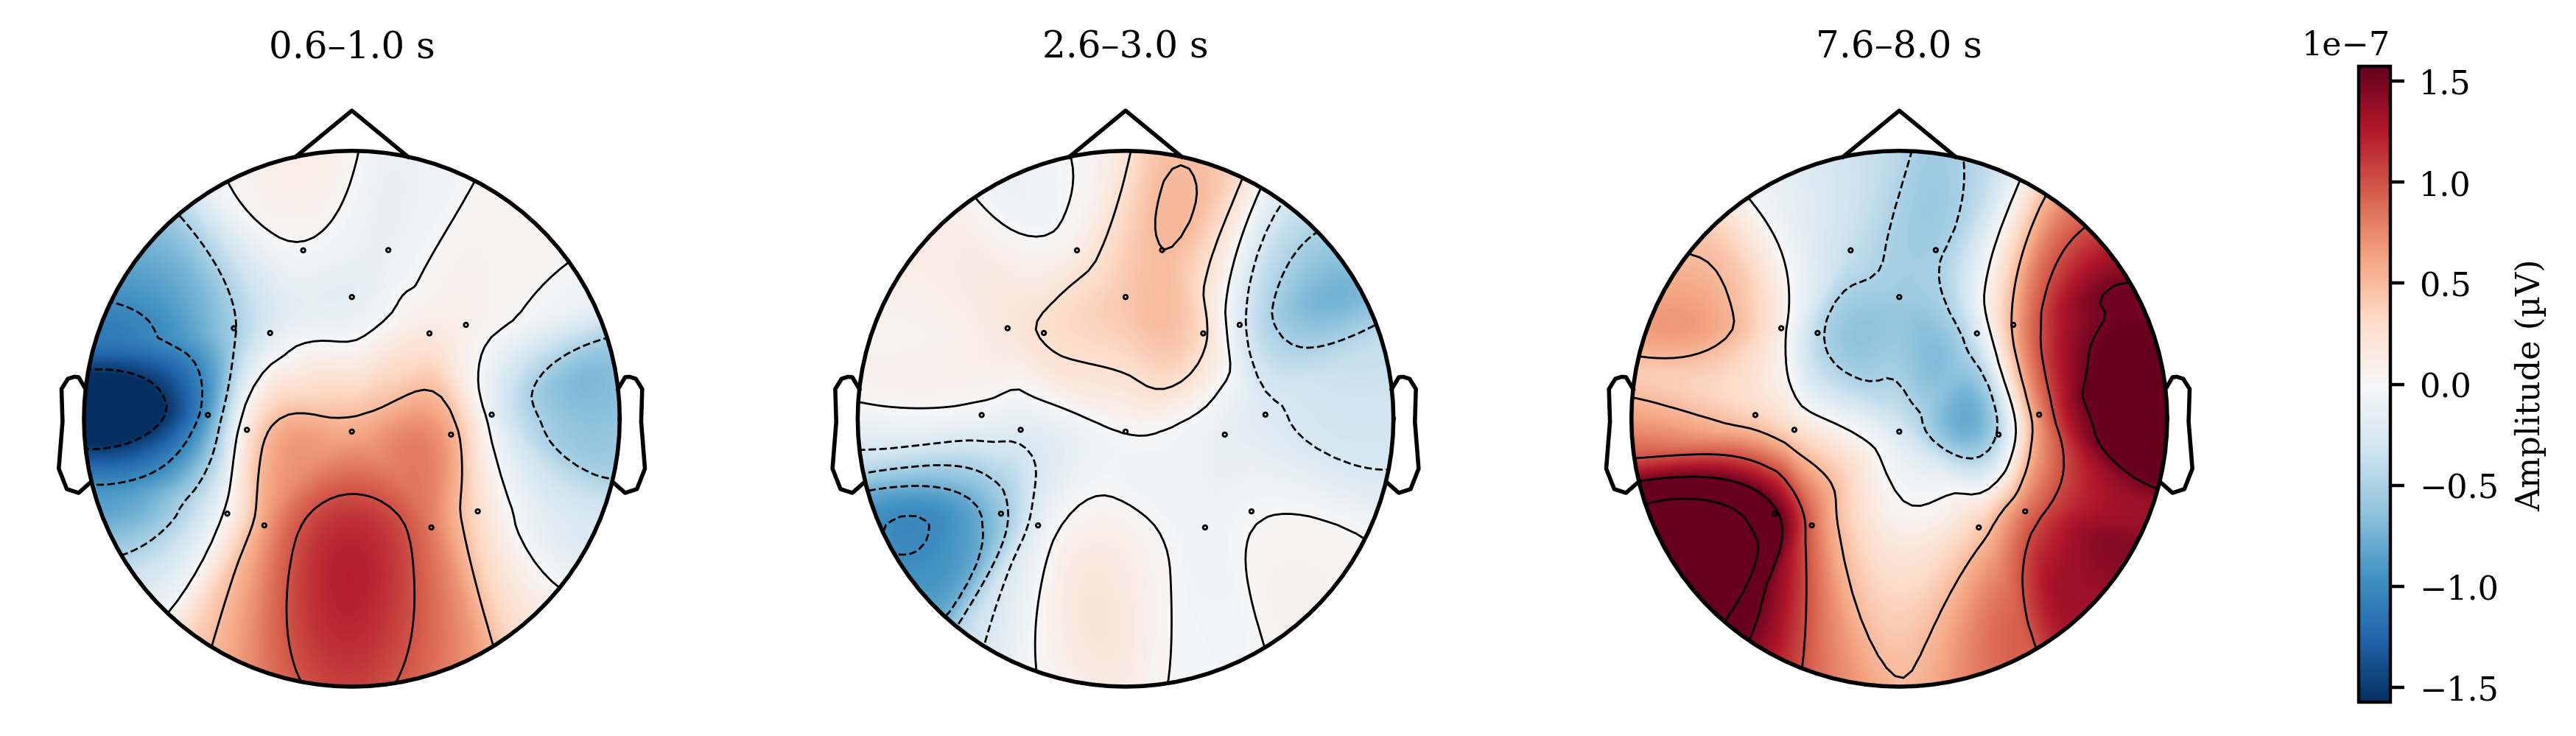

In [55]:
fig, axes = plt.subplots(1, len(topomaps), figsize=(12, 4))
vlim = max(abs(np.concatenate(topomaps)))

for i, topo in enumerate(topomaps):
    im, _ = mne.viz.plot_topomap(
        topo,
        evoked_index.info,
        axes=axes[i],
        cmap='RdBu_r',
        vlim=(-vlim, vlim),
        show=False
    )
    axes[i].set_title(f"{time_windows[i][0]}–{time_windows[i][1]} s")

# ---- Add shared colorbar ----
cbar = fig.colorbar(im, ax=axes, shrink=0.7)
cbar.set_label("Amplitude (µV)")

#plt.tight_layout()
plt.show()


## Feature Extraction

In [51]:
def load_data():
    EEG_FREQ = 125
    TRIAL_PERIOD = 9

    EMG_CONFIG_DICT = {
        'rms_windowsize' : 32,
        'rms_stepsize' : 16,
        'hampel_windowsize' : 100,
        'hampel_sigma' : 2,
        'hampel_plot_option' : [False, None],
        'include_EMG' : True
    }

    REJECT_CONFIG_DICT = {
        'EEG_epoch_rejection_tolerance' : 6,
        'EMG_epoch_rejection_tolerance' : 6
    }

    base_dir = Path().resolve() / 'data'
    load_ins = load_datasets(base_dir = base_dir)

    EEG_files = load_ins.find_flex_files(
        subjects = 'subject_8',
        modality = 'EEG',
        fingers = 'thumb',
        prefix = 'flex'
    )

    EMG_files = load_ins.find_flex_files(
        subjects = 'subject_8',
        modality = 'EMG',
        fingers = 'thumb',
        prefix = 'flex'
    )

    marker_files = load_ins.find_flex_files(
        subjects = 'subject_8',
        modality = 'Markers',
        fingers = 'thumb',
        prefix = 'flex'
    )

    EEG_ins = EEG_preprocessing(fs = 125, bandpass_lowcut = 0.05, bandpass_highcut = 32, trial_period = 9, trim_period = 3)
    EMG_ins = EMG_preprocessing(fs = 2000, bandpass_lowcut = 20, bandpass_highcut = 450, trial_period = 9, trim_period = 3)
    reject_ins = RejectBadEpochs(base_dir = base_dir)

    SELECT_EXP = 0
    EEG, RMS, EMG, epochs_overview = load_ins.load_datasets(
        path_to_EEG_files = EEG_files[SELECT_EXP],
        path_to_EMG_files = EMG_files[SELECT_EXP],
        EEG_preprocessing_func = EEG_ins.preprocessing_routine,
        EMG_preprocessing_func = EMG_ins.preprocessing_routine,
        EMG_config_dict = EMG_CONFIG_DICT
    )

    markers = load_ins.load_datasets_marker(marker_files)[SELECT_EXP]

    reject_mask = reject_ins.reject_routine(data_file_per_finger = EEG_files,
                                            epochs_overview = epochs_overview,
                                            EEG_data = EEG,
                                            RMS_data = RMS,
                                            reject_config_dict = REJECT_CONFIG_DICT,
                                            EEG_useable_channels = None)
    
    reject_mask_indices = np.where(reject_mask)[0]

    total_epochs = sum(epochs_overview)
    EEG_epoch = EEG.reshape(total_epochs, EEG.shape[0] // total_epochs, EEG.shape[1])
    RMS_epoch = RMS.reshape(total_epochs, RMS.shape[0] // total_epochs, RMS.shape[1])
    EMG_epoch = EMG.reshape(total_epochs, EMG.shape[0] // total_epochs, EMG.shape[1])
    
    EEG_epoch_clean = EEG_epoch[~reject_mask]
    RMS_epoch_clean = RMS_epoch[~reject_mask]
    EMG_epoch_clean = EMG_epoch[~reject_mask]
    print(EEG_epoch_clean.shape, RMS_epoch_clean.shape, EMG_epoch_clean.shape)

    return EEG_epoch_clean, total_epochs

def sliding_chunks(data, window_size, step_size): 
    """
    data: (samples, channels)

    Returns:
        chunks: (n_windows, window_size, channels)
    """
    from numpy.lib.stride_tricks import sliding_window_view
    windows = sliding_window_view(
        data,
        window_shape=window_size,
        axis=0
    )

    return windows[::step_size]

features_ins = FeatureExtraction(fs = 125)
window_size = 250
step_size = 25

EEG, total_epochs = load_data()


all_windows = np.array([                        
    sliding_chunks(epo, window_size, step_size)
    for epo in EEG
])                                            # Shape (num_epochs, num_windows, channels, window_samples)

samples = EEG.shape[0]
print(all_windows.shape)

print('samples:', samples)
print(f'Remaining sampels: {((samples - window_size) / step_size) + 1}')


 C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_8\EEG\flex_thumb_finger_2026-02-19 11-13-00.csv
Original shape (34509, 16)
EEG_trim shape: (33750, 16)


 C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_8\EMG\flex_thumb_finger_2026-02-19 11-13-00.csv
Original shape (551800, 3)
EEG_trim shape: (540000, 3)

3

File: C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_8\EEG\flex_thumb_finger_2026-02-19 11-13-00.csv, Epoch shape: 30
------------auto-rejecting EEG------------
In detect_bad_epochs_ptp - data shape: (30, 1125, 16)

Epoch 2
Max diff: 18.76397553330213
Channels exceeding: [ 0 10]

Epoch 13
Max diff: 1.7508841137410371
Channels exceeding: [14]

------------auto-rejecting EMG------------
In detect_bad_epochs_ptp - data shape: (30, 1125, 3)

Epoch 4
Max diff: 0.005598036991709701
Channels exceeding: [0 1]

Epoch 7
Max diff: 0.004045896838658861
Channels exceeding: [0]

Epoch 8
Max diff: 0.0022598123667465567
Channels exceeding: [0]



In [ ]:
import scipy.stats as stats
def extract_statistical_features(signal):
    mean = np.mean(signal)
    median = np.median(signal)
    std_dev = np.std(signal)
    variance = np.var(signal)
    skewness = stats.skew(signal)
    kurtosis = stats.kurtosis(signal)
    range_val = np.ptp(signal)
    abs_area = np.sum(np.abs(signal))
    
    features = {
        'Mean': mean,
        'Median': median,
        'Standard Deviation': std_dev,
        'Variance': variance,
        'Skewness': skewness,
        'Kurtosis': kurtosis,
        'Range': range_val,
        'Absolute Area' : abs_area
    }
    
    return features

def extract_time_domain_features(signal):
    rms = np.sqrt(np.mean(signal**2))
    zero_crossings = ((signal[:-1] * signal[1:]) < 0).sum()
    autocorrelation = np.correlate(signal, signal, mode='full')[len(signal)-1]
    mean_abs_dev = np.mean(np.abs(signal - np.mean(signal)))
    max_val = np.max(signal)
    min_val = np.min(signal)
    signal_energy = np.sum(signal**2)
    
    features = {
        'RMS': rms,
        'Zero Crossings': zero_crossings,
        'Autocorrelation': autocorrelation,
        'Mean Absolute Deviation': mean_abs_dev,
        'Max Value': max_val,
        'Min Value': min_val,
        'Signal Energy': signal_energy
    }
    
    return features

def extract_features_from_windows(X, feature_func_dict : Callable):

    num_epochs, num_windows, n_channels, _ = X.shape

    all_rows = []
    track_info = []

    for epo in range(num_epochs):
        for win in range(num_windows):

            row_features = {}
            row_info = {}

            for ch in range(n_channels):

                signal = X[epo, win, ch, :]

                for func_name, feature_func in feature_func_dict.items():
                    
                    feats = feature_func(signal)

                    # rename features per channel
                    for feat_name, value in feats.items():
                        col_name = f'ch{ch}_{func_name}_{feat_name}'
                        row_features[col_name] = value

            # optional tracking info
            row_info['epoch'] = epo
            row_info['window'] = win

            all_rows.append(row_features)
            track_info.append(row_info)

    df = pd.DataFrame(all_rows)
    df_info = pd.DataFrame(track_info)

    return df, df_info                  # (num_epochs, num_windows (time steps - LSTM sequence), feature)

def create_window_labels(df):

    Y = np.zeros(len(df), dtype=int)

    Y[df['window'] < 12] = 0          # Rest
    Y[(df['window'] >= 12) &
      (df['window'] < 24)] = 1        # Contract
    Y[df['window'] >= 24] = 2         # Release

    return Y

def df_to_lstm(normalized_df, num_epochs, num_windows):

    feature_cols = [
        c for c in normalized_df.columns
    ]

    X = normalized_df[feature_cols].values

    X = X.reshape(num_epochs,
                  num_windows,
                  len(feature_cols))

    return X


In [70]:
feature_func_dict = {
    'stat' : extract_statistical_features,
    'time domain' : extract_time_domain_features
}

combined_features_df, info_df = extract_features_from_windows(X = all_windows, feature_func_dict = feature_func_dict)

### Normalize

In [73]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply the scaler to normalize the data
normalized_data = scaler.fit_transform(combined_features_df)

# Convert the result back into a DataFrame
normalized_df = pd.DataFrame(normalized_data, columns = combined_features_df.columns)

Y = create_window_labels(info_df)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

# Initialize the model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Initialize RFE with the model and number of features to select
rfe = RFE(model, n_features_to_select=10)

# Fit RFE
rfe = rfe.fit(normalized_df, Y)

# Get the selected features
selected_features = normalized_df.columns[rfe.support_]         # support_ , ranking_
print("Selected Features:", selected_features)


In [ ]:
normalized_labeled_df = normalized_df.copy()
normalized_labeled_df['class'] = Y

kruskal_results = {}
for feature in normalized_labeled_df.columns:
    if feature == 'class':
        continue
    class_0 = normalized_labeled_df[feature][normalized_labeled_df['class'] == 0]
    class_1 = normalized_labeled_df[feature][normalized_labeled_df['class'] == 1]
    class_2 = normalized_labeled_df[feature][normalized_labeled_df['class'] == 2]
    kruskal_results[feature] = stats.kruskal(class_0, class_1).pvalue

kruskal_results_df = pd.DataFrame(list(kruskal_results.items()), columns=['Feature', 'P-value'])

print(len(kruskal_results_df[kruskal_results_df['P-value'] < 0.05]))
kruskal_results_df[kruskal_results_df['P-value'] < 0.05]

for feature, value in kruskal_results.items():
    if value < 0.05:
        print(feature, value)

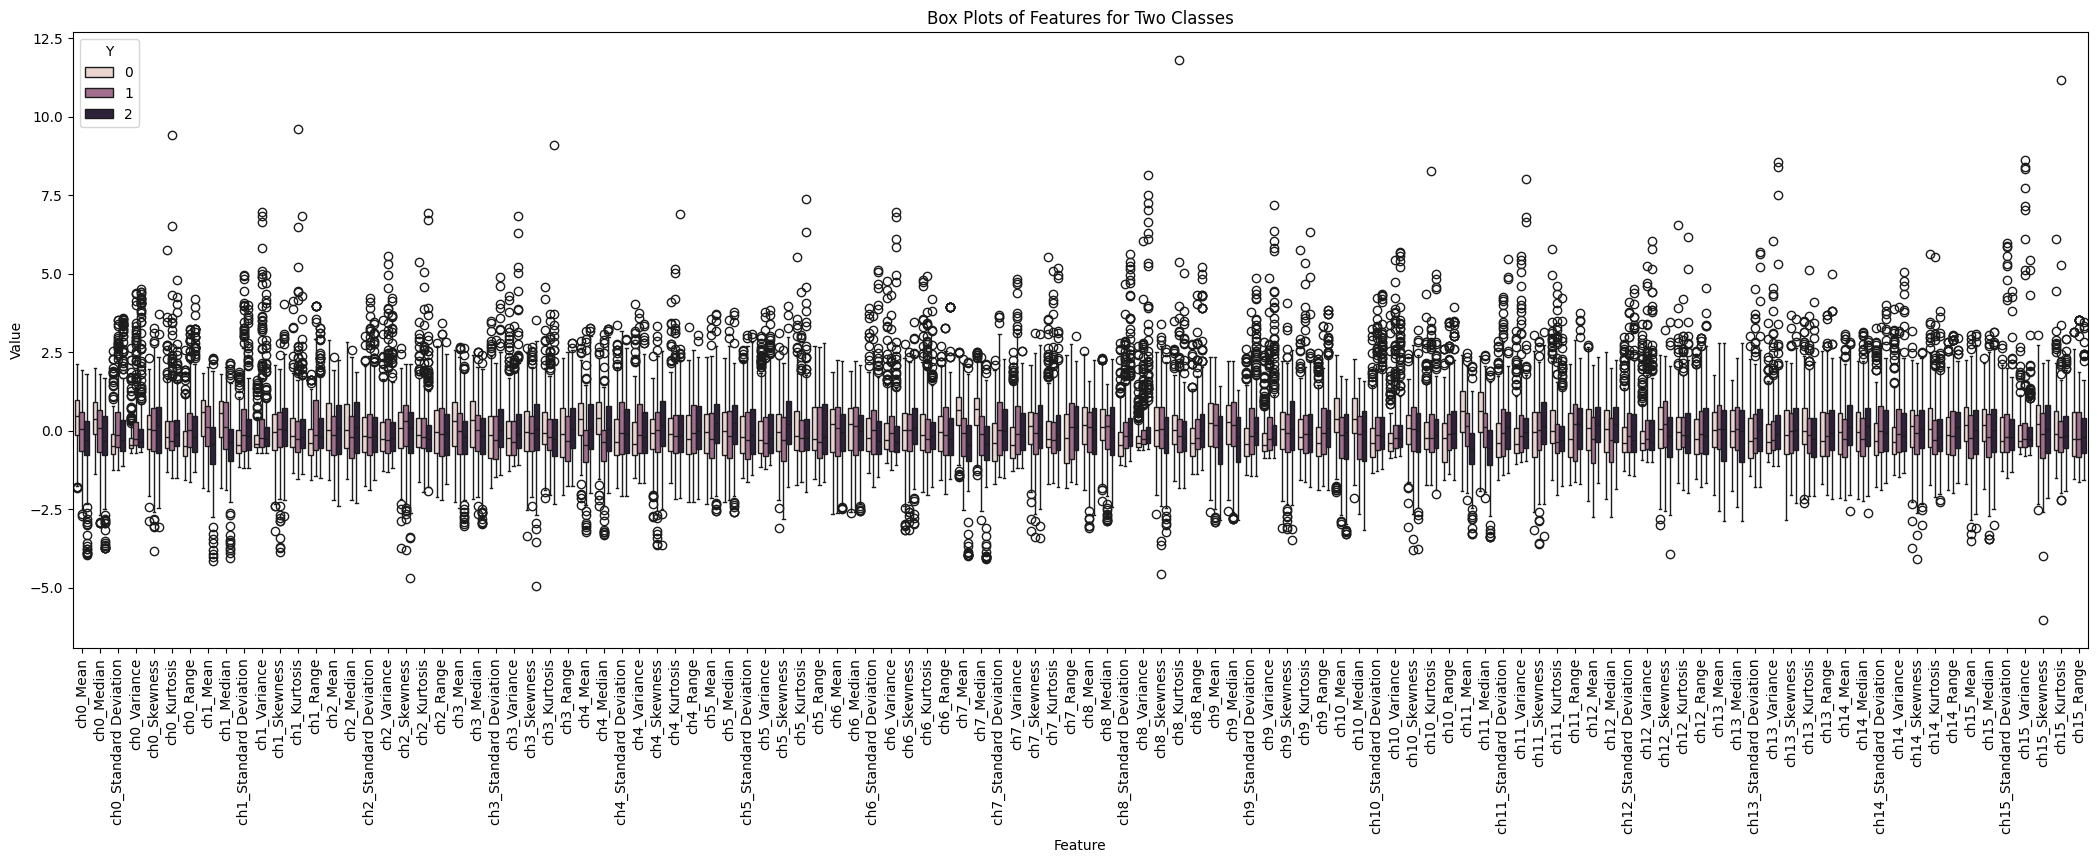

In [ ]:
import seaborn as sns
# Plot box plots for each feature
plt.figure(figsize=(26, 8))

melted_df = pd.melt(normalized_labeled_df, id_vars='class', var_name='Feature', value_name='Value')
sns.boxplot(x='Feature', y='Value', hue='class', data=melted_df)
plt.xticks(rotation=90)
plt.title('Box Plots of Features for Two Classes')
plt.savefig('KW_test')
plt.show()

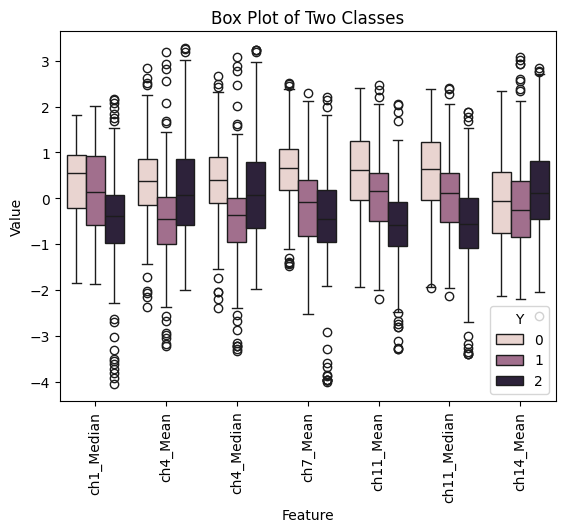

In [ ]:
features_to_plot =['ch1_Median', 'ch4_Mean', 'ch4_Median', 'ch7_Mean', 'ch11_Mean', 'ch11_Median', 'ch14_Mean']
melted_df = pd.melt(normalized_labeled_df, id_vars='class', var_name='Feature', value_name='Value')
melted_df = melted_df[melted_df['Feature'].isin(features_to_plot)]
sns.boxplot(x='Feature', y='Value', hue='class', data=melted_df)
plt.xticks(rotation=90)
plt.title('Box Plot of Two Classes')
plt.savefig('box_plot_feature1.png')
plt.show()